## INTRODUCCIÓN

### 📡 Telecom X - Análisis de Evasión de Clientes (Churn)

El objetivo de este análisis es comprender los factores que influyen en la cancelación de clientes (Churn) en Telecom X.

A través de un proceso de limpieza, exploración y visualización de datos, se busca identificar patrones que permitan proponer estrategias para reducir la evasión.

## IMPORTACIÓN DE LIBRERÍAS

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

plt.style.use("default")

## CARGA DE DATOS DESDE LA API

In [10]:
import requests
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## EXPLORACIÓN INICIAL

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer.gender            7267 non-null   str    
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   str    
 5   customer.Dependents        7267 non-null   str    
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   str    
 8   phone.MultipleLines        7267 non-null   str    
 9   internet.InternetService   7267 non-null   str    
 10  internet.OnlineSecurity    7267 non-null   str    
 11  internet.OnlineBackup      7267 non-null   str    
 12  internet.DeviceProtection  7267 non-null   str    
 13  internet.TechSupport       7267 non-null   str    
 14  int

In [12]:
df.dtypes

customerID                       str
Churn                            str
customer.gender                  str
customer.SeniorCitizen         int64
customer.Partner                 str
customer.Dependents              str
customer.tenure                int64
phone.PhoneService               str
phone.MultipleLines              str
internet.InternetService         str
internet.OnlineSecurity          str
internet.OnlineBackup            str
internet.DeviceProtection        str
internet.TechSupport             str
internet.StreamingTV             str
internet.StreamingMovies         str
account.Contract                 str
account.PaperlessBilling         str
account.PaymentMethod            str
account.Charges.Monthly      float64
account.Charges.Total            str
dtype: object

In [13]:
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [14]:
df.isnull().sum()

customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

## LIMPIEZA Y TRATAMIENTO

In [16]:
df.columns = df.columns.str.lower().str.replace(".", "_")

Convertir totalcharges a numérico

In [17]:
df["account_charges_total"] = pd.to_numeric(
    df["account_charges_total"], errors="coerce"
)

df["account_charges_total"].fillna(
    df["account_charges_total"].median(), inplace=True
)

C:\Users\aecq\AppData\Local\Temp\ipykernel_9460\2678473960.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["account_charges_total"].fillna(


0        593.30
1        542.40
2        280.85
3       1237.85
4        267.40
         ...   
7262     742.90
7263    1873.70
7264      92.75
7265    4627.65
7266    3707.60
Name: account_charges_total, Length: 7267, dtype: float64

In [18]:
for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

C:\Users\aecq\AppData\Local\Temp\ipykernel_9460\3483331084.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [19]:
df["churn"] = df["churn"].map({"Yes":1, "No":0})

## COLUMNA CUENTAS_DIARIAS

In [20]:
df["cuentas_diarias"] = df["account_charges_monthly"] / 30

## ANÁLISIS DESCRIPTIVO

In [21]:
df.describe()

,churn,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,cuentas_diarias
count,7043.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.265370,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.441561,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,1.000000,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


## DISTRIBUCIÓN DE EVASIÓN

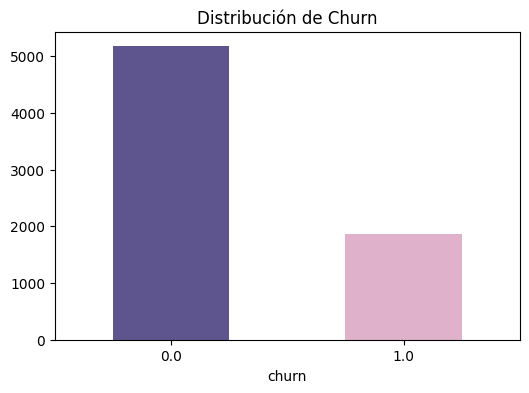

In [22]:
plt.figure(figsize=(6,4))

colors = ["#5E548E", "#E0B1CB"]

df["churn"].value_counts().plot(
    kind="bar",
    color=colors
)

plt.title("Distribución de Churn")
plt.xticks(rotation=0)
plt.show()

Se observa que existe una proporción importante de clientes que cancelan el servicio. Esto indica que la empresa enfrenta un nivel significativo de evasión que debe ser atendido estratégicamente.

## EVASIÓN POR VARIABLES CATEGÓRICAS

### Tipo de contrato

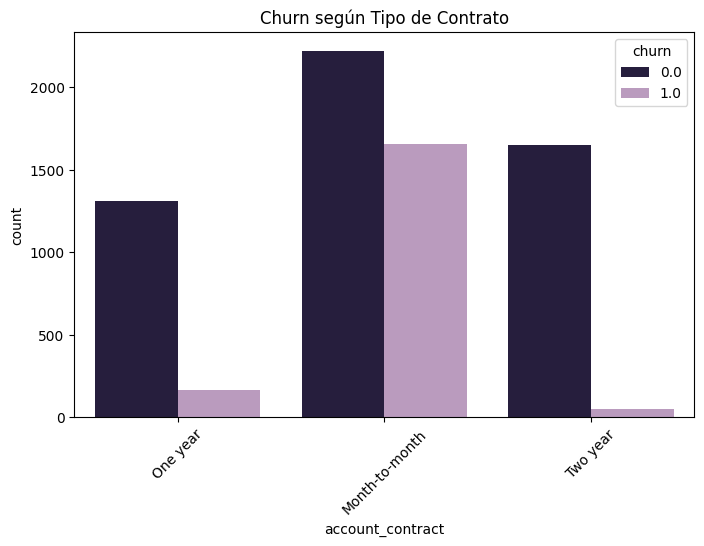

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="account_contract",
    hue="churn",
    palette=["#231942", "#BE95C4"]
)

plt.xticks(rotation=45)
plt.title("Churn según Tipo de Contrato")
plt.show()

### Método de pago

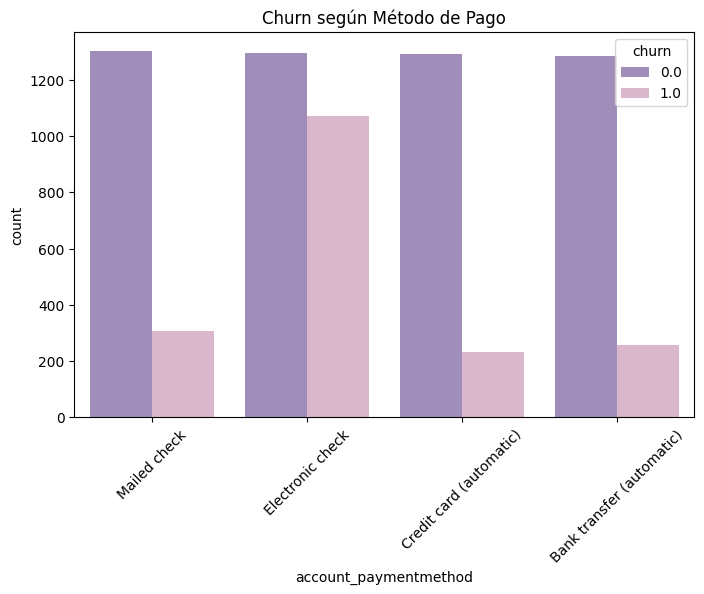

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="account_paymentmethod",
    hue="churn",
    palette=["#9F86C0", "#E0B1CB"]
)

plt.xticks(rotation=45)
plt.title("Churn según Método de Pago")
plt.show()

## EVASIÓN POR VARIABLES NUMÉRICAS

### Tenure

C:\Users\aecq\AppData\Local\Temp\ipykernel_9460\1083626216.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


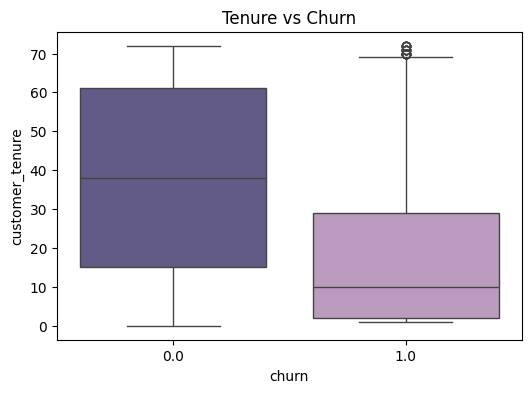

In [25]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="churn",
    y="customer_tenure",
    palette=["#5E548E", "#BE95C4"]
)

plt.title("Tenure vs Churn")
plt.show()

### Total Gastado

C:\Users\aecq\AppData\Local\Temp\ipykernel_9460\2645248577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


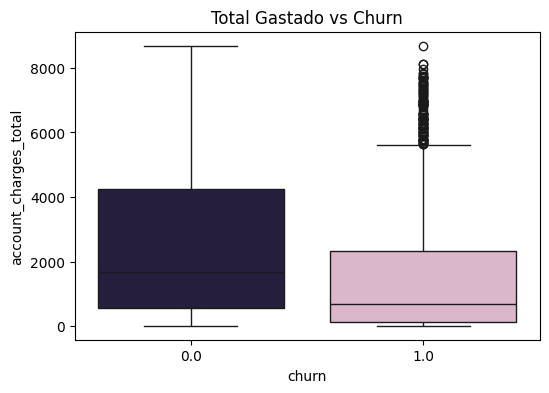

In [26]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="churn",
    y="account_charges_total",
    palette=["#231942", "#E0B1CB"]
)

plt.title("Total Gastado vs Churn")
plt.show()

## CORRELACIÓN

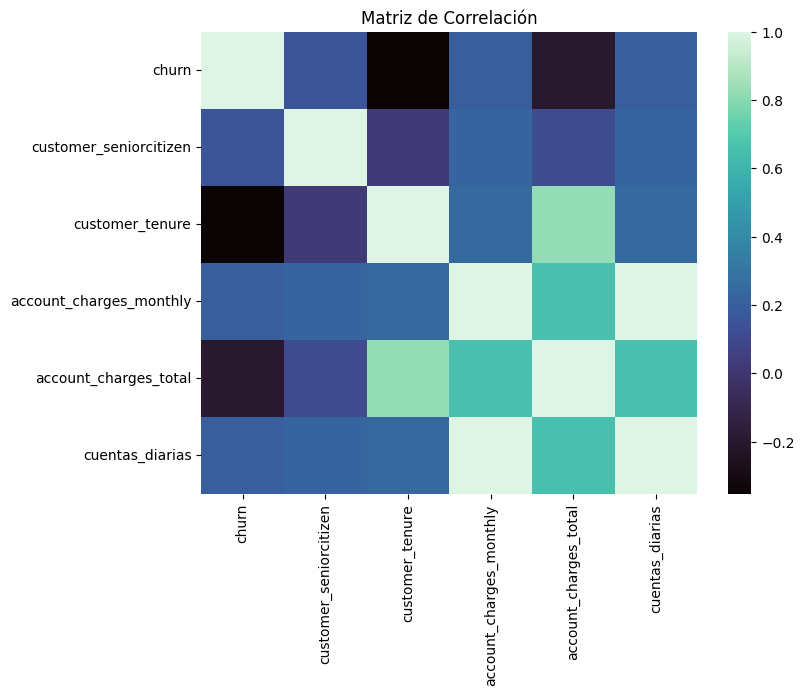

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="mako",
    annot=False
)

plt.title("Matriz de Correlación")
plt.show()

## Conclusiones

Después del análisis exploratorio se identificaron patrones claros asociados a la evasión de clientes:

- Los clientes con contrato mensual presentan la mayor tasa de cancelación. Esto sugiere que la flexibilidad del contrato facilita la salida del servicio.

- La antigüedad (tenure) es un factor clave. Los clientes con menos tiempo en la empresa tienen mayor probabilidad de cancelar, lo que indica que el riesgo es más alto en las primeras etapas del ciclo de vida del cliente.

- Los clientes que pagan cargos mensuales más altos muestran mayor tendencia al churn. El precio parece ser un factor sensible en la decisión de permanencia.

- Algunos métodos de pago concentran mayor proporción de cancelaciones, lo que podría estar relacionado con menor compromiso o mayor facilidad de interrupción del servicio.

- El total gastado acumulado tiende a ser menor en clientes que cancelan, lo cual es coherente con su menor antigüedad.

En general, el churn no parece ser aleatorio, sino que está influenciado principalmente por el tipo de contrato, el tiempo de permanencia y el nivel de facturación mensual.

## Recomendaciones

A partir de los hallazgos obtenidos, se proponen las siguientes acciones:

- Incentivar la migración de contratos mensuales hacia planes anuales mediante descuentos o beneficios adicionales.

- Implementar un programa de fidelización enfocado en clientes nuevos, especialmente durante los primeros meses de servicio.

- Revisar la percepción de valor en planes con cargos mensuales altos, evaluando posibles ajustes o mejoras en los beneficios ofrecidos.

- Crear un sistema de alerta temprana para identificar clientes con alto riesgo (contrato mensual + baja antigüedad + alta facturación mensual).

- Analizar en mayor profundidad los métodos de pago asociados con mayor churn para detectar posibles fricciones en el proceso.

Estas acciones pueden contribuir a reducir la tasa de evasión y mejorar la retención de clientes a mediano plazo.